<a href="https://colab.research.google.com/github/shruti-2562/FML/blob/colab-pdf/prac4_FMl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree # Added for decision tree visualization
import matplotlib.pyplot as plt # Added for decision tree visualization
import pandas as pd # Import pandas

uploaded = files.upload()

Saving loan_approval_dataset.csv to loan_approval_dataset (1).csv



FIRST FIVE RECORDS

   ApplicantID Gender  Age MaritalStatus     Education EmploymentStatus  \
0         1001   Male   22        Single  Non-Graduate         Business   
1         1002   Male   22        Single      Graduate         Business   
2         1003   Male   49       Married      Graduate         Business   
3         1004   Male   26        Single  Non-Graduate         Salaried   
4         1005   Male   45        Single  Non-Graduate    Self-Employed   

   AnnualIncome  LoanAmount  LoanTerm  CreditScore PreviousLoanDefault  \
0        414053      173158       180          602                 Yes   
1        423962      364951       120          563                 Yes   
2        912052      321571        60          692                 Yes   
3        556417      544331        60          685                 Yes   
4        785397      200814       180          585                 Yes   

   ExistingEMI PropertyOwnership LoanApproved  
0        10674                No   

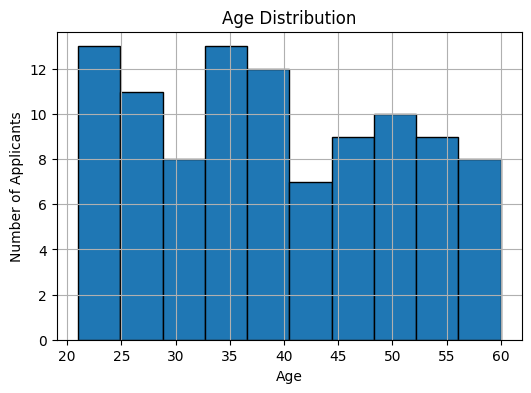

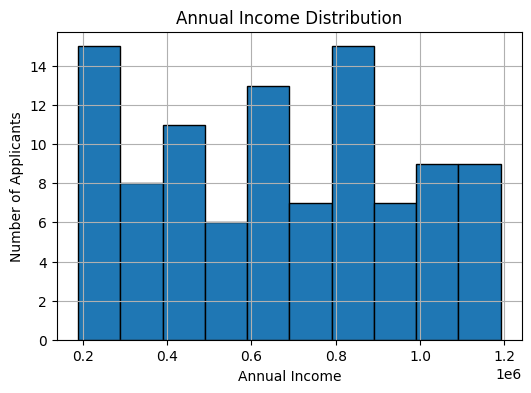

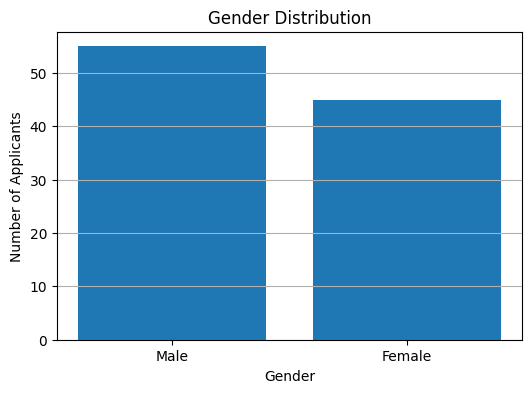

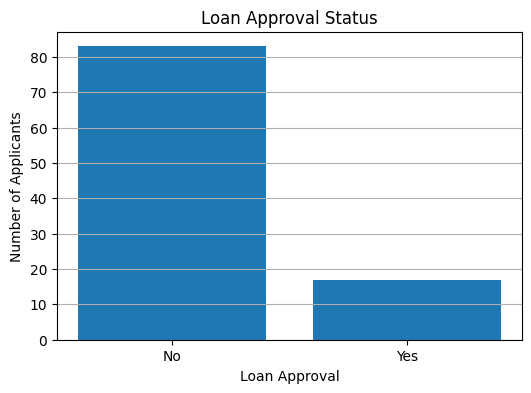

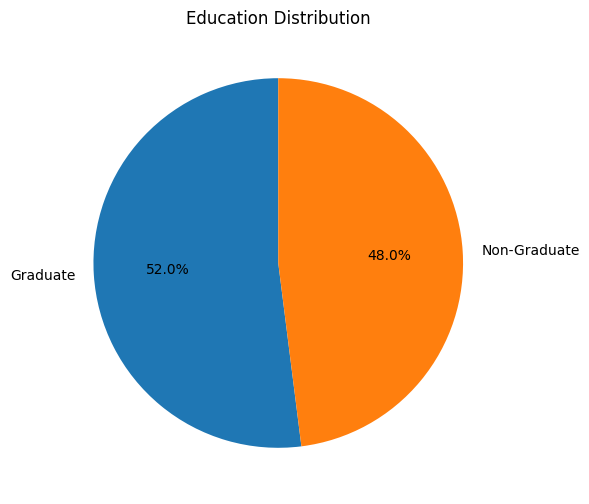

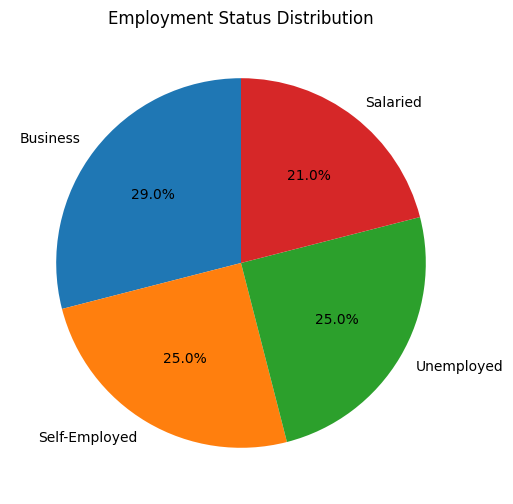

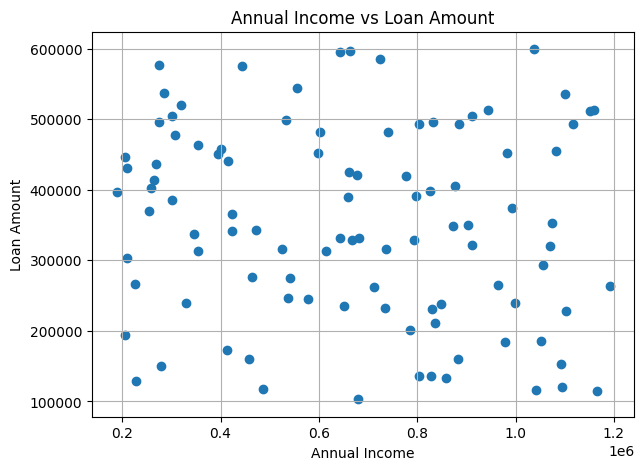

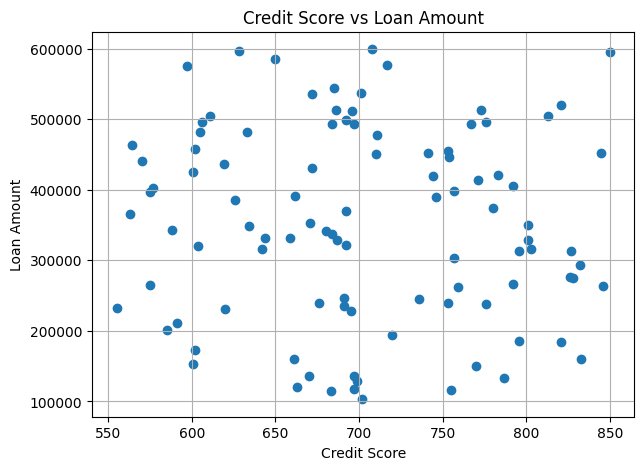

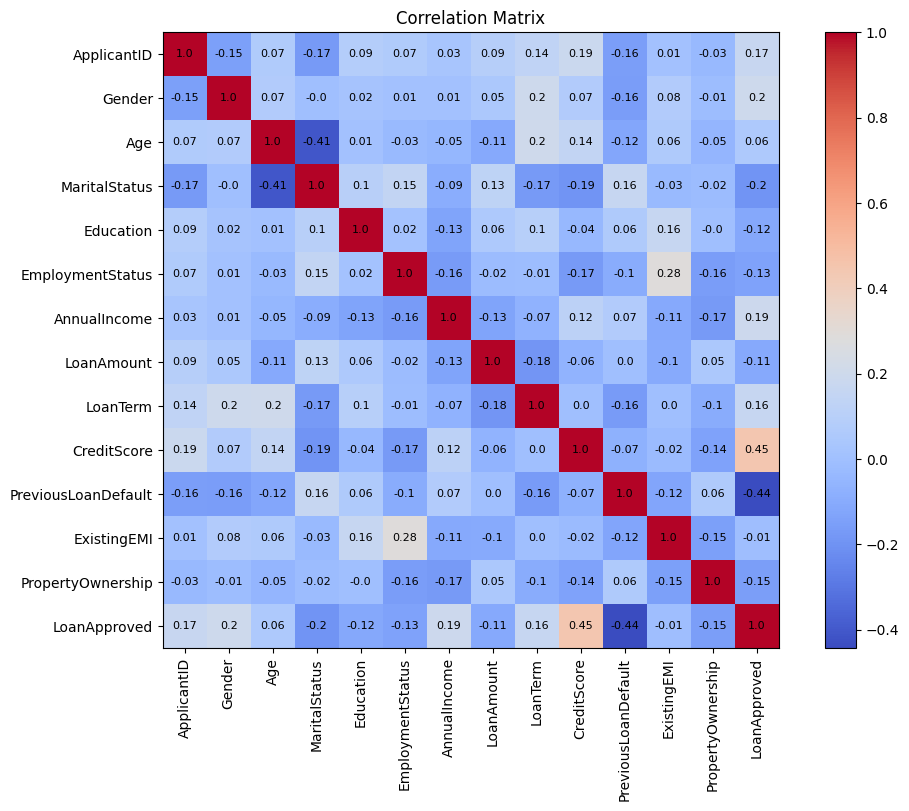


FEATURES USED FOR TRAINING

Index(['Gender', 'Age', 'MaritalStatus', 'Education', 'EmploymentStatus',
       'AnnualIncome', 'LoanAmount', 'LoanTerm', 'CreditScore',
       'PreviousLoanDefault', 'ExistingEMI', 'PropertyOwnership'],
      dtype='object')

TARGET VARIABLE

LoanApproved

TRAINING DATA SHAPE
(80, 12)

TESTING DATA SHAPE
(20, 12)


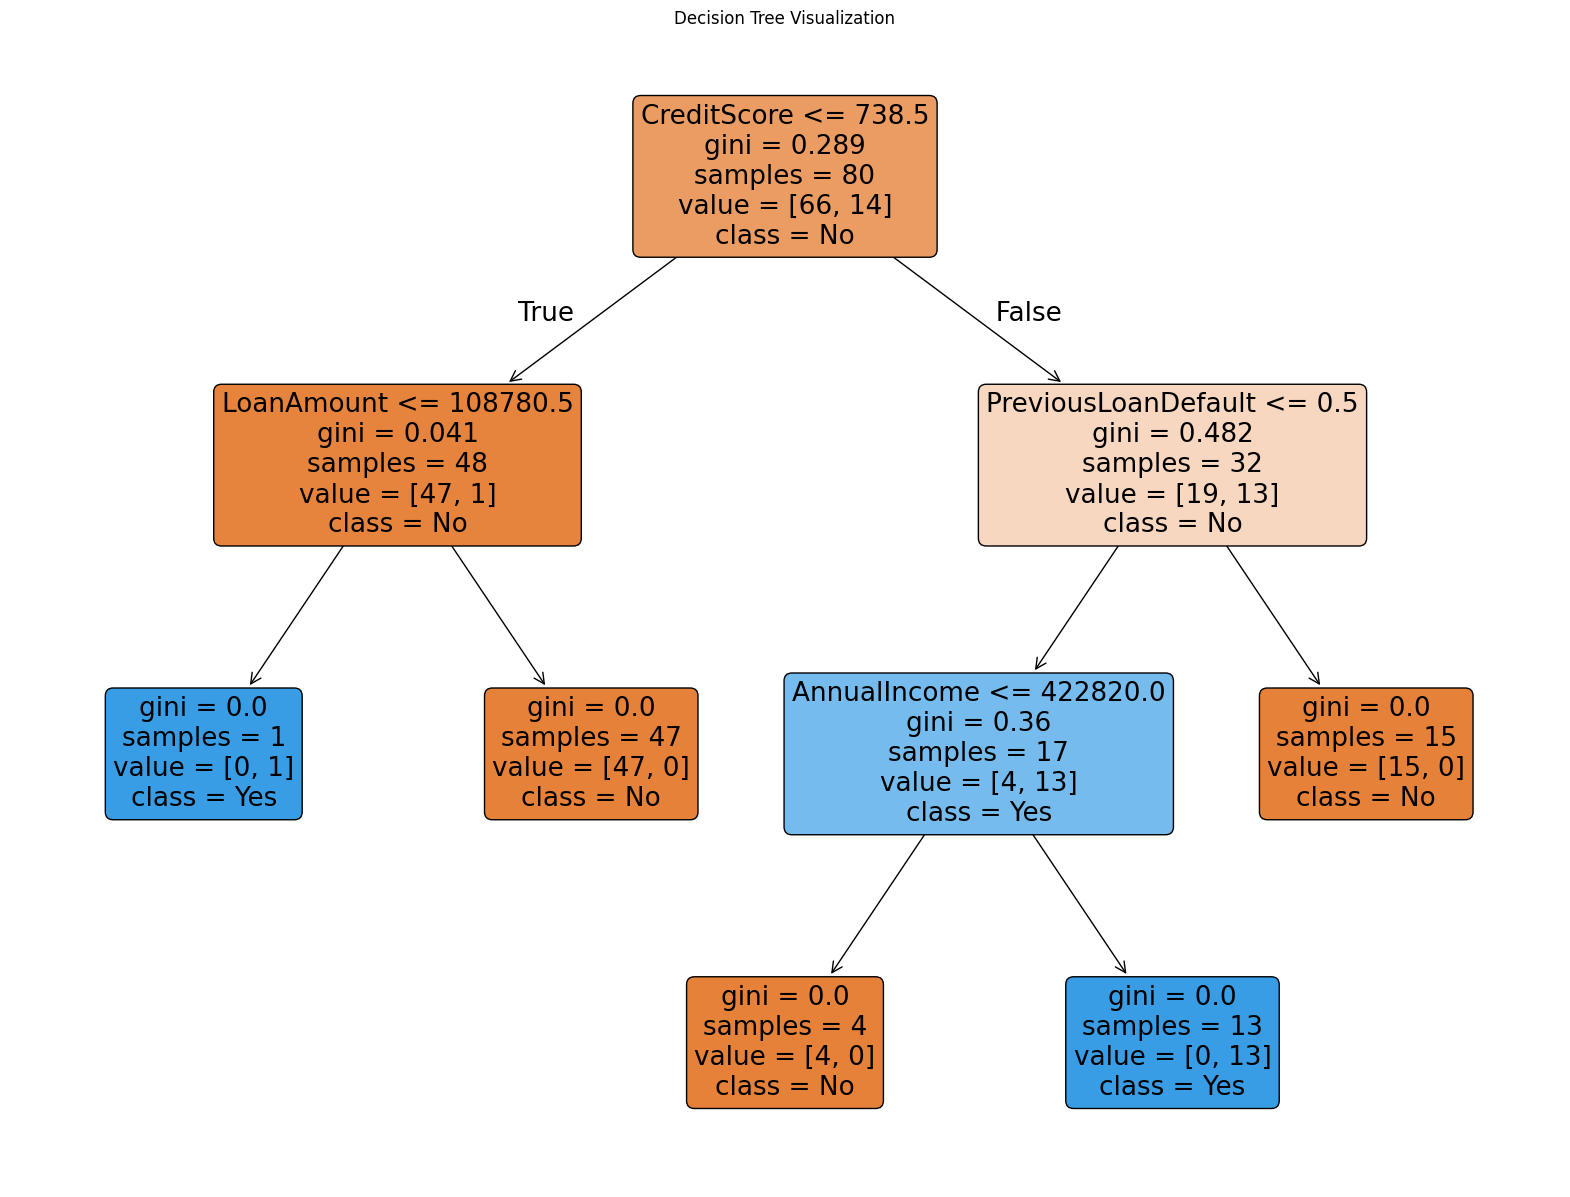


MODELS TRAINED SUCCESSFULLY
Decision Tree Model : Ready
Naive Bayes Model   : Ready

ENTER APPLICANT DETAILS
Gender (Male/Female): Female
Age: 25
Marital Status (Single/Married): Single
Education (Graduate/Non-Graduate): Graduate
Employment (Salaried/Business/Self-Employed/Unemployed): Business
Annual Income: 450000
Loan Amount: 200000
Loan Term (Months): 48
Credit Score: 720
Previous Loan Default (Yes/No): No
Existing EMI: 3000
Property Ownership (Yes/No): Yes

PREDICTION
Decision Tree Prediction : No
Naive Bayes Prediction   : No

DECISION TREE PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00         3

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


NAIVE BAYES PERFORMANC

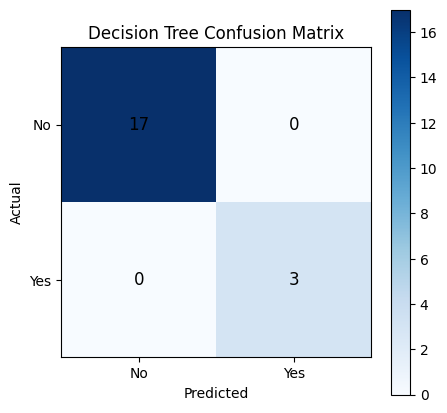

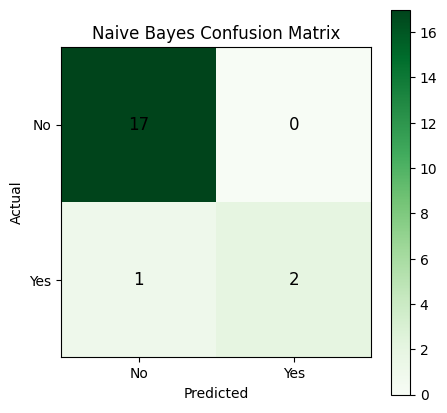


MODEL COMPARISON
           Model  Accuracy  Precision    Recall  F1 Score
0  Decision Tree      1.00        1.0  1.000000       1.0
1    Naive Bayes      0.95        1.0  0.666667       0.8


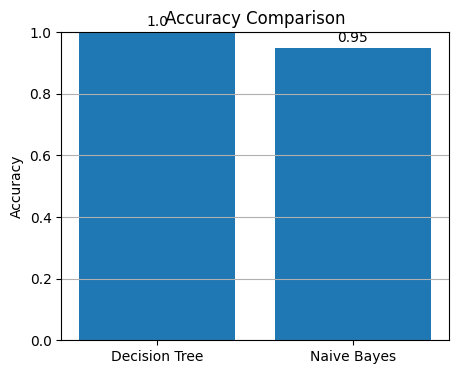

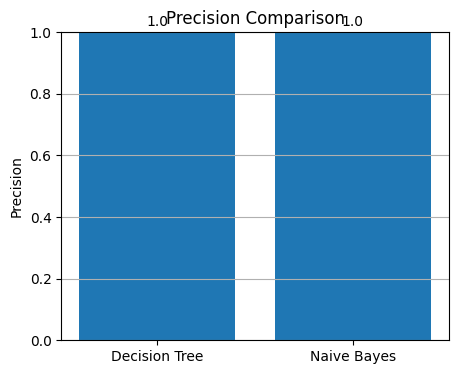

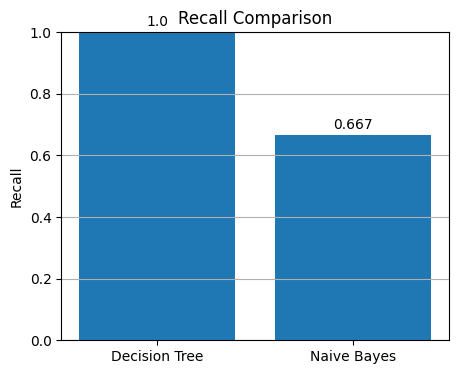

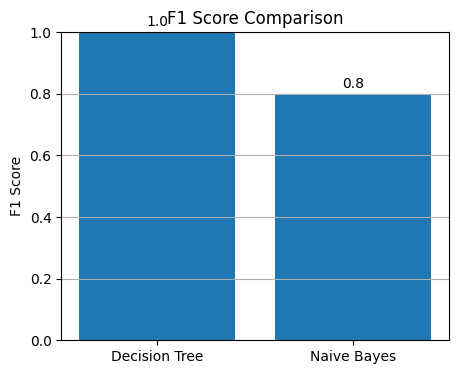


Decision Tree performed better than Naive Bayes based on Accuracy.


In [5]:

df = pd.read_csv("loan_approval_dataset.csv")

print("\nFIRST FIVE RECORDS\n")
print(df.head())

print("\nLAST FIVE RECORDS\n")
print(df.tail())

print("\nDATASET INFORMATION\n")
print(df.info())

print("\nSTATISTICAL SUMMARY\n")
print(df.describe(include="all"))

print("\nMISSING VALUES\n")
print(df.isnull().sum())

plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=10, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Applicants")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df["AnnualIncome"], bins=10, edgecolor="black")
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Applicants")
plt.grid()
plt.show()

gender = df["Gender"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender.index, gender.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")
plt.grid(axis="y")
plt.show()

approval = df["LoanApproved"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(approval.index, approval.values)
plt.title("Loan Approval Status")
plt.xlabel("Loan Approval")
plt.ylabel("Number of Applicants")
plt.grid(axis="y")
plt.show()

education = df["Education"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    education.values,
    labels=education.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Education Distribution")
plt.show()

employment = df["EmploymentStatus"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    employment.values,
    labels=employment.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Employment Status Distribution")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(
    df["AnnualIncome"],
    df["LoanAmount"]
)
plt.title("Annual Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.grid()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(
    df["CreditScore"],
    df["LoanAmount"]
)
plt.title("Credit Score vs Loan Amount")
plt.xlabel("Credit Score")
plt.ylabel("Loan Amount")
plt.grid()
plt.show()
encoders = {}

categorical_columns = [
    "Gender",
    "MaritalStatus",
    "Education",
    "EmploymentStatus",
    "PreviousLoanDefault",
    "PropertyOwnership",
    "LoanApproved"
]

for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column].astype(str))
    encoders[column] = le

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            round(correlation.iloc[i, j], 2),
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

plt.title("Correlation Matrix")

plt.show()

X = df.drop(
    columns=[
        "ApplicantID",
        "LoanApproved"
    ]
)

y = df["LoanApproved"]

print("\nFEATURES USED FOR TRAINING\n")
print(X.columns)

print("\nTARGET VARIABLE\n")
print("LoanApproved")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTRAINING DATA SHAPE")
print(X_train.shape)

print("\nTESTING DATA SHAPE")
print(X_test.shape)

decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)
# Decision Tree Visualization
plt.figure(figsize=(20,15))

plot_tree(
    decision_tree,
    feature_names=X.columns.tolist(),
    class_names=encoders["LoanApproved"].classes_.tolist(),
    filled=True,
    rounded=True
)

plt.title("Decision Tree Visualization")
plt.show()
naive_bayes = GaussianNB()

naive_bayes.fit(
    X_train,
    y_train
)

print("\n====================================")
print("MODELS TRAINED SUCCESSFULLY")
print("====================================")

print("Decision Tree Model : Ready")

print("Naive Bayes Model   : Ready")
print("\n======================================")
print("ENTER APPLICANT DETAILS")
print("======================================")

gender = input("Gender (Male/Female): ")
age = int(input("Age: "))
marital = input("Marital Status (Single/Married): ")
education = input("Education (Graduate/Non-Graduate): ")
employment = input("Employment (Salaried/Business/Self-Employed/Unemployed): ")
income = float(input("Annual Income: "))
loan = float(input("Loan Amount: "))
term = int(input("Loan Term (Months): "))
credit = int(input("Credit Score: "))
default = input("Previous Loan Default (Yes/No): ")
emi = float(input("Existing EMI: "))
property_owner = input("Property Ownership (Yes/No): ")

new_data = pd.DataFrame({
    "Gender":[gender],
    "Age":[age],
    "MaritalStatus":[marital],
    "Education":[education],
    "EmploymentStatus":[employment],
    "AnnualIncome":[income],
    "LoanAmount":[loan],
    "LoanTerm":[term],
    "CreditScore":[credit],
    "PreviousLoanDefault":[default],
    "ExistingEMI":[emi],
    "PropertyOwnership":[property_owner]
})

for column in [
    "Gender",
    "MaritalStatus",
    "Education",
    "EmploymentStatus",
    "PreviousLoanDefault",
    "PropertyOwnership"
]:
    new_data[column] = encoders[column].transform(new_data[column].astype(str))

dt_prediction = decision_tree.predict(new_data)
nb_prediction = naive_bayes.predict(new_data)

print("\n======================================")
print("PREDICTION")
print("======================================")

print("Decision Tree Prediction :",
      encoders["LoanApproved"].inverse_transform(dt_prediction)[0])

print("Naive Bayes Prediction   :",
      encoders["LoanApproved"].inverse_transform(nb_prediction)[0])

dt_test = decision_tree.predict(X_test)
nb_test = naive_bayes.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_test)
dt_precision = precision_score(y_test, dt_test)
dt_recall = recall_score(y_test, dt_test)
dt_f1 = f1_score(y_test, dt_test)

nb_accuracy = accuracy_score(y_test, nb_test)
nb_precision = precision_score(y_test, nb_test)
nb_recall = recall_score(y_test, nb_test)
nb_f1 = f1_score(y_test, nb_test)

print("\n====================================")
print("DECISION TREE PERFORMANCE")
print("====================================")

print("Accuracy :", round(dt_accuracy,4))
print("Precision:", round(dt_precision,4))
print("Recall   :", round(dt_recall,4))
print("F1 Score :", round(dt_f1,4))

print("\nClassification Report\n")
print(classification_report(y_test, dt_test))

print("\n====================================")
print("NAIVE BAYES PERFORMANCE")
print("====================================")

print("Accuracy :", round(nb_accuracy,4))
print("Precision:", round(nb_precision,4))
print("Recall   :", round(nb_recall,4))
print("F1 Score :", round(nb_f1,4))

print("\nClassification Report\n")
print(classification_report(y_test, nb_test))

dt_cm = confusion_matrix(y_test, dt_test)

plt.figure(figsize=(5,5))
plt.imshow(dt_cm, cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1],["No","Yes"])
plt.yticks([0,1],["No","Yes"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, dt_cm[i,j],
                 ha="center",
                 va="center",
                 fontsize=12,
                 color="black")

plt.colorbar()
plt.show()

nb_cm = confusion_matrix(y_test, nb_test)

plt.figure(figsize=(5,5))
plt.imshow(nb_cm, cmap="Greens")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1],["No","Yes"])
plt.yticks([0,1],["No","Yes"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, nb_cm[i,j],
                 ha="center",
                 va="center",
                 fontsize=12,
                 color="black")

plt.colorbar()
plt.show()

comparison = pd.DataFrame({
    "Model":["Decision Tree","Naive Bayes"],
    "Accuracy":[dt_accuracy,nb_accuracy],
    "Precision":[dt_precision,nb_precision],
    "Recall":[dt_recall,nb_recall],
    "F1 Score":[dt_f1,nb_f1]
})

print("\n====================================")
print("MODEL COMPARISON")
print("====================================")
print(comparison)

metrics = ["Accuracy","Precision","Recall","F1 Score"]

for metric in metrics:
    plt.figure(figsize=(5,4))
    plt.bar(
        comparison["Model"],
        comparison[metric]
    )
    plt.ylim(0,1)
    plt.title(metric + " Comparison")
    plt.ylabel(metric)

    for i, value in enumerate(comparison[metric]):
        plt.text(i, value + 0.02, round(value,3), ha="center")

    plt.grid(axis="y")
    plt.show()

if dt_accuracy > nb_accuracy:
    print("\nDecision Tree performed better than Naive Bayes based on Accuracy.")
elif nb_accuracy > dt_accuracy:
    print("\nNaive Bayes performed better than Decision Tree based on Accuracy.")
else:
    print("\nBoth models performed equally based on Accuracy.")
